# В этом ноутбуке мы с вами обучим MNIST и создадим собственную архитектуру FC сети

In [1]:
import matplotlib.pyplot as plt
import random
import numpy as np

In [15]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms

# Check Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [3]:
# MNIST dataset 
train_dataset = torchvision.datasets.MNIST(root='data', 
                                           train=True, 
                                           transform=transforms.ToTensor(),  
                                           download=True)

test_dataset = torchvision.datasets.MNIST(root='data', 
                                          train=False, 
                                          transform=transforms.ToTensor())

In [4]:
train_dataset

Dataset MNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor()

Посмотрим что находится в датасете:

In [14]:
train_dataset[0]

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 

In [ ]:
# Размерность [1, 28, 28], вероятно, сообщает о том, что используется один канал для изображения 28*28
train_dataset[0][0].shape

torch.Size([1, 28, 28])

In [19]:
image = train_dataset[0][0][0].cpu().numpy()
image

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

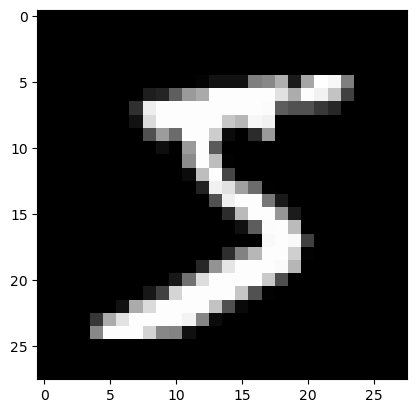

In [5]:
plt.imshow(image, cmap="gray")

In [68]:
image, label = train_dataset[0]
image = image.numpy().transpose(1, 2, 0).squeeze() 
# image[0].numpy() # То же самое, что и строка выше - какой смысл в этих преобразованиях?
print(image.shape)
image

(28, 28)


array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

Визуализуем изображения и GT:

In [69]:
def visualize_random_mnist(dataset):
    # Выбираем случайный индекс в датасете
    index = random.randint(0, len(dataset) - 1)
    image, label = dataset[index] # Image size [1, 28, 28]
    
    # Преобразуем тензор в numpy массив и меняем оси для отображения
    image = image.numpy().transpose(1, 2, 0)

    print(f'Image shape: {image.shape}')
    print(f'Squeeze shape: {image.squeeze().shape}')
    
    # Создаем фигуру и оси
    fig, ax = plt.subplots()
    
    # Отображаем изображение
    ax.imshow(image.squeeze(), cmap='gray')
    
    # Устанавливаем заголовок с ground truth значением
    ax.set_title(f'Ground Truth: {label}')
    
    # Показываем изображение
    plt.show()

Image shape: (28, 28, 1)
Squeeze shape: (28, 28)


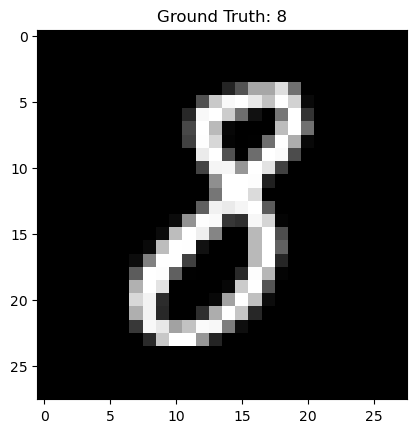

In [72]:
visualize_random_mnist(train_dataset)

Создадим сеть:

In [93]:
# Fully connected neural network
class NeuralNetFC(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(NeuralNetFC, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size) 
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, num_classes)  
    
    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out

In [ ]:
model = NeuralNetFC(28*28, 100, 10)
x = torch.randn(2, 28*28)
model(x)

# Вывод содержит два элемента, так как на вхд поступило такое же их количество

tensor([[-0.1193, -0.1935,  0.0024, -0.0070, -0.0307, -0.0242,  0.2505,  0.1138,
          0.0971,  0.0392],
        [ 0.2660, -0.1718,  0.1538,  0.2053,  0.4536, -0.2162,  0.2205,  0.2596,
          0.1821, -0.2379]], grad_fn=<AddmmBackward0>)

---

Посмотрим как сделать флаттерн нашего изображения и зачем он нужен:

In [118]:
x = train_dataset[0][0]
x.shape

torch.Size([1, 28, 28])

In [ ]:
# Эмуляция реального входа
x = torch.unsqueeze(x, 0)
x.shape # размерности: [1 - размер batch, (1 - число каналов, 28, 28) - x]

torch.Size([1, 1, 28, 28])

так будет ошибка:

In [97]:
model(x)

RuntimeError: mat1 and mat2 shapes cannot be multiplied (28x28 and 784x100)

Вытягиваем изображение в вектор:

In [ ]:
# Reshape input to (batch_size, input_size) 

# Так как исходная размерность изображения (x) сейчас [1, 1, 28, 28]
# функция ниже берет размерность первой компоненты - 1 (batch) и для второй перемножает размерности оставшихся компонент (input).
# таким образом происходит "вытягивание"
x = x.view(x.size(0), -1) 
x.shape 

torch.Size([1, 784])

In [99]:
model(x)

tensor([[ 0.0747, -0.1007,  0.0298, -0.1708,  0.0264, -0.1113,  0.1687,  0.0536,
         -0.0437, -0.1073]], grad_fn=<AddmmBackward0>)

---

Итоговая модель:

In [16]:
# Fully connected neural network
class NeuralNetFC(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(NeuralNetFC, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size) 
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, num_classes)  
    
    def forward(self, x):
        x = x.view(x.size(0), -1)
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out

In [17]:
# Define Hyper-parameters 
input_size = 28*28
hidden_size = 50
num_classes = 10
num_epochs = 5
batch_size = 64
learning_rate = 0.001

In [18]:
model = NeuralNetFC(input_size, hidden_size, num_classes)

In [19]:
from torchsummary import summary

# инициализирую автокодировщик
model = model.to(device)
summary(model, (1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 50]          39,250
              ReLU-2                   [-1, 50]               0
            Linear-3                   [-1, 10]             510
Total params: 39,760
Trainable params: 39,760
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.15
Estimated Total Size (MB): 0.16
----------------------------------------------------------------


In [20]:
# Data loader
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, 
                                           batch_size=batch_size, 
                                           shuffle=True)

test_loader = torch.utils.data.DataLoader(dataset=test_dataset, 
                                          batch_size=batch_size, 
                                          shuffle=False)

Что же лежит в батче:

In [107]:
data_iter = iter(train_loader)
images, labels = next(data_iter)

In [108]:
images.shape, labels.shape

(torch.Size([64, 1, 28, 28]), torch.Size([64]))

In [109]:
def show_batch_images(loader):
    # Получаем один батч из loader
    data_iter = iter(loader)
    images, labels = next(data_iter)
    
    # Создаем фигуру для отображения изображений
    plt.figure(figsize=(12, 8))
    
    # Определяем количество изображений в батче
    batch_size = images.size(0)
    
    # Определяем количество строк для отображения
    num_rows = (batch_size + 7) // 8  # Целочисленное деление с округлением вверх
    
    # Определяем общее количество изображений для отображения (округляем до ближайшего числа, кратного 8)
    total_images = num_rows * 8
    
    # Отображаем каждое изображение
    for i in range(total_images):
        plt.subplot(num_rows, 8, i + 1)  # Используем num_rows для определения количества строк
        if i < batch_size:
            plt.imshow(images[i].numpy().squeeze(), cmap='gray')  # Используем cmap='gray' для одноканальных изображений
            plt.title(f'Label: {labels[i].item()}')
        else:
            plt.imshow(np.zeros_like(images[0].numpy().squeeze()), cmap='gray')  # фон для пустых изображений
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

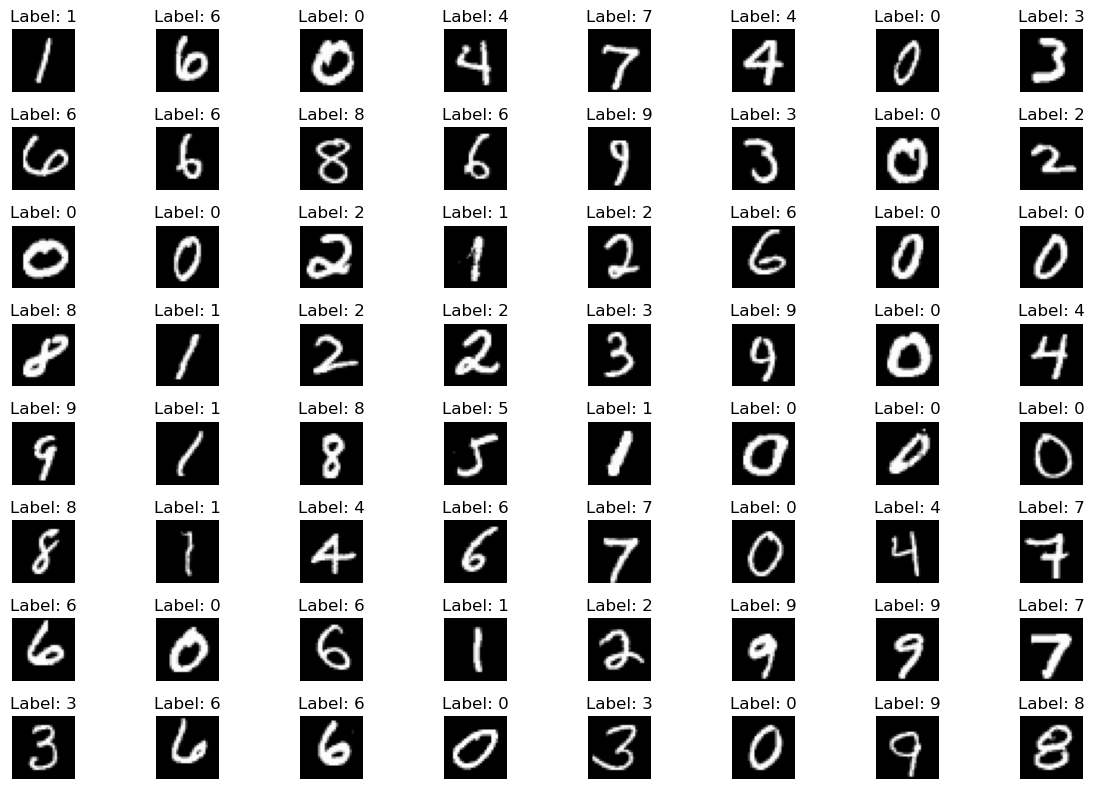

In [110]:
show_batch_images(train_loader)

Число спусков за эпоху:

In [43]:
len(train_loader)

938

In [21]:
# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)  

In [22]:
model = model.to(device)

# Train the model
total_step = len(train_loader)
for epoch in range(num_epochs):
    print(f"Start of {epoch+1} Epoch:")
    for i, (images, labels) in enumerate(train_loader):  
        # Move tensors to the configured device
        images = images.to(device)
        labels = labels.to(device)
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backprpagation and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        if (i+1) % 150 == 0:
            print ('Epoch [{}/{}], Step [{}/{}], Loss: {:.4f}' 
                   .format(epoch+1, num_epochs, i+1, total_step, loss.item()))

Start of 1 Epoch:
Epoch [1/5], Step [150/938], Loss: 0.4788
Epoch [1/5], Step [300/938], Loss: 0.4159
Epoch [1/5], Step [450/938], Loss: 0.4543
Epoch [1/5], Step [600/938], Loss: 0.1625
Epoch [1/5], Step [750/938], Loss: 0.1222
Epoch [1/5], Step [900/938], Loss: 0.1651
Start of 2 Epoch:
Epoch [2/5], Step [150/938], Loss: 0.1521
Epoch [2/5], Step [300/938], Loss: 0.1694
Epoch [2/5], Step [450/938], Loss: 0.1986
Epoch [2/5], Step [600/938], Loss: 0.3042
Epoch [2/5], Step [750/938], Loss: 0.3175
Epoch [2/5], Step [900/938], Loss: 0.1311
Start of 3 Epoch:
Epoch [3/5], Step [150/938], Loss: 0.1565
Epoch [3/5], Step [300/938], Loss: 0.1018
Epoch [3/5], Step [450/938], Loss: 0.1451
Epoch [3/5], Step [600/938], Loss: 0.3649
Epoch [3/5], Step [750/938], Loss: 0.2605
Epoch [3/5], Step [900/938], Loss: 0.2384
Start of 4 Epoch:
Epoch [4/5], Step [150/938], Loss: 0.1037
Epoch [4/5], Step [300/938], Loss: 0.0957
Epoch [4/5], Step [450/938], Loss: 0.3065
Epoch [4/5], Step [600/938], Loss: 0.1529
Epoc

In [112]:
# Save the model checkpoint
torch.save(model.state_dict(), 'model.pth')

Загрузим модель и оценим ее на тесте:

In [113]:
# Параметры модели
input_size = 28*28  
hidden_size = 50
num_classes = 10

# Создаем экземпляр модели
model = NeuralNetFC(input_size, hidden_size, num_classes)

# Загружаем сохраненные параметры в модель
model.load_state_dict(torch.load('model.pth'))

model.to(device)
model.eval()

C:\Users\mazurenko\AppData\Local\Temp\ipykernel_9436\3400069194.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('model.pth'))


NeuralNetFC(
  (fc1): Linear(in_features=784, out_features=50, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=50, out_features=10, bias=True)
)

In [48]:
# Test the model
# In the test phase, don't need to compute gradients (for memory efficiency)
with torch.no_grad():
    correct = 0
    total = 0
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    print('Accuracy of the network on test images: {} %'.format(100 * correct / total))

Accuracy of the network on test images: 96.4 %


---

JIT конвертация:

In [49]:
# Конвертируем модель в TorchScript
scripted_model = torch.jit.script(model)

# Сохраняем скриптованную модель
scripted_model.save('scripted_model.pth')

In [50]:
# Загрузка скриптованной модели
model = torch.jit.load('scripted_model.pth')
model.to(device)
model.eval()

RecursiveScriptModule(
  original_name=NeuralNetFC
  (fc1): RecursiveScriptModule(original_name=Linear)
  (relu): RecursiveScriptModule(original_name=ReLU)
  (fc2): RecursiveScriptModule(original_name=Linear)
)

In [51]:
with torch.no_grad():
    correct = 0
    total = 0
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    print('Accuracy of the network on test images: {} %'.format(100 * correct / total))

Accuracy of the network on test images: 96.4 %


Убедимся, что нам больше не нужно иметь саму архитектуру чтоб запустить сеть (удобно для прода):

In [52]:
import torch

# Загрузка скриптованной модели
model = torch.jit.load('scripted_model.pth')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
model.eval()
with torch.no_grad():
    x = torch.randn(1,1,28,28).to(device)
    print(model(x))

tensor([[  1.9217,   5.4079,   9.7609,   3.2506, -14.7507,  -5.6248,  -3.2790,
           0.9078,  -5.2683, -13.1340]], device='cuda:0')


---